# CIFAR-10 Image Classifier — Improved Version
**FSE560 Term Project — Topic T3**

This notebook trains a CNN on CIFAR-10 and evaluates it with accuracy, precision, recall, and a confusion matrix.

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

print('TensorFlow version:', tf.__version__)
print('All imports successful!')

TensorFlow version: 2.21.0
All imports successful!


In [2]:
# ── Cell 2: Load and preprocess data ─────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# One-hot encode labels
y_cat_train = to_categorical(y_train, 10)
y_cat_test  = to_categorical(y_test,  10)

labels = ["airplane", "automobile", "bird", "cat", "deer",
          "dog", "frog", "horse", "ship", "truck"]

print(f'Training set:   {X_train.shape}')
print(f'Test set:       {X_test.shape}')
print(f'Classes:        {labels}')

C:\Users\imello\AppData\Roaming\Python\Python313\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training set:   (50000, 32, 32, 3)
Test set:       (10000, 32, 32, 3)
Classes:        ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


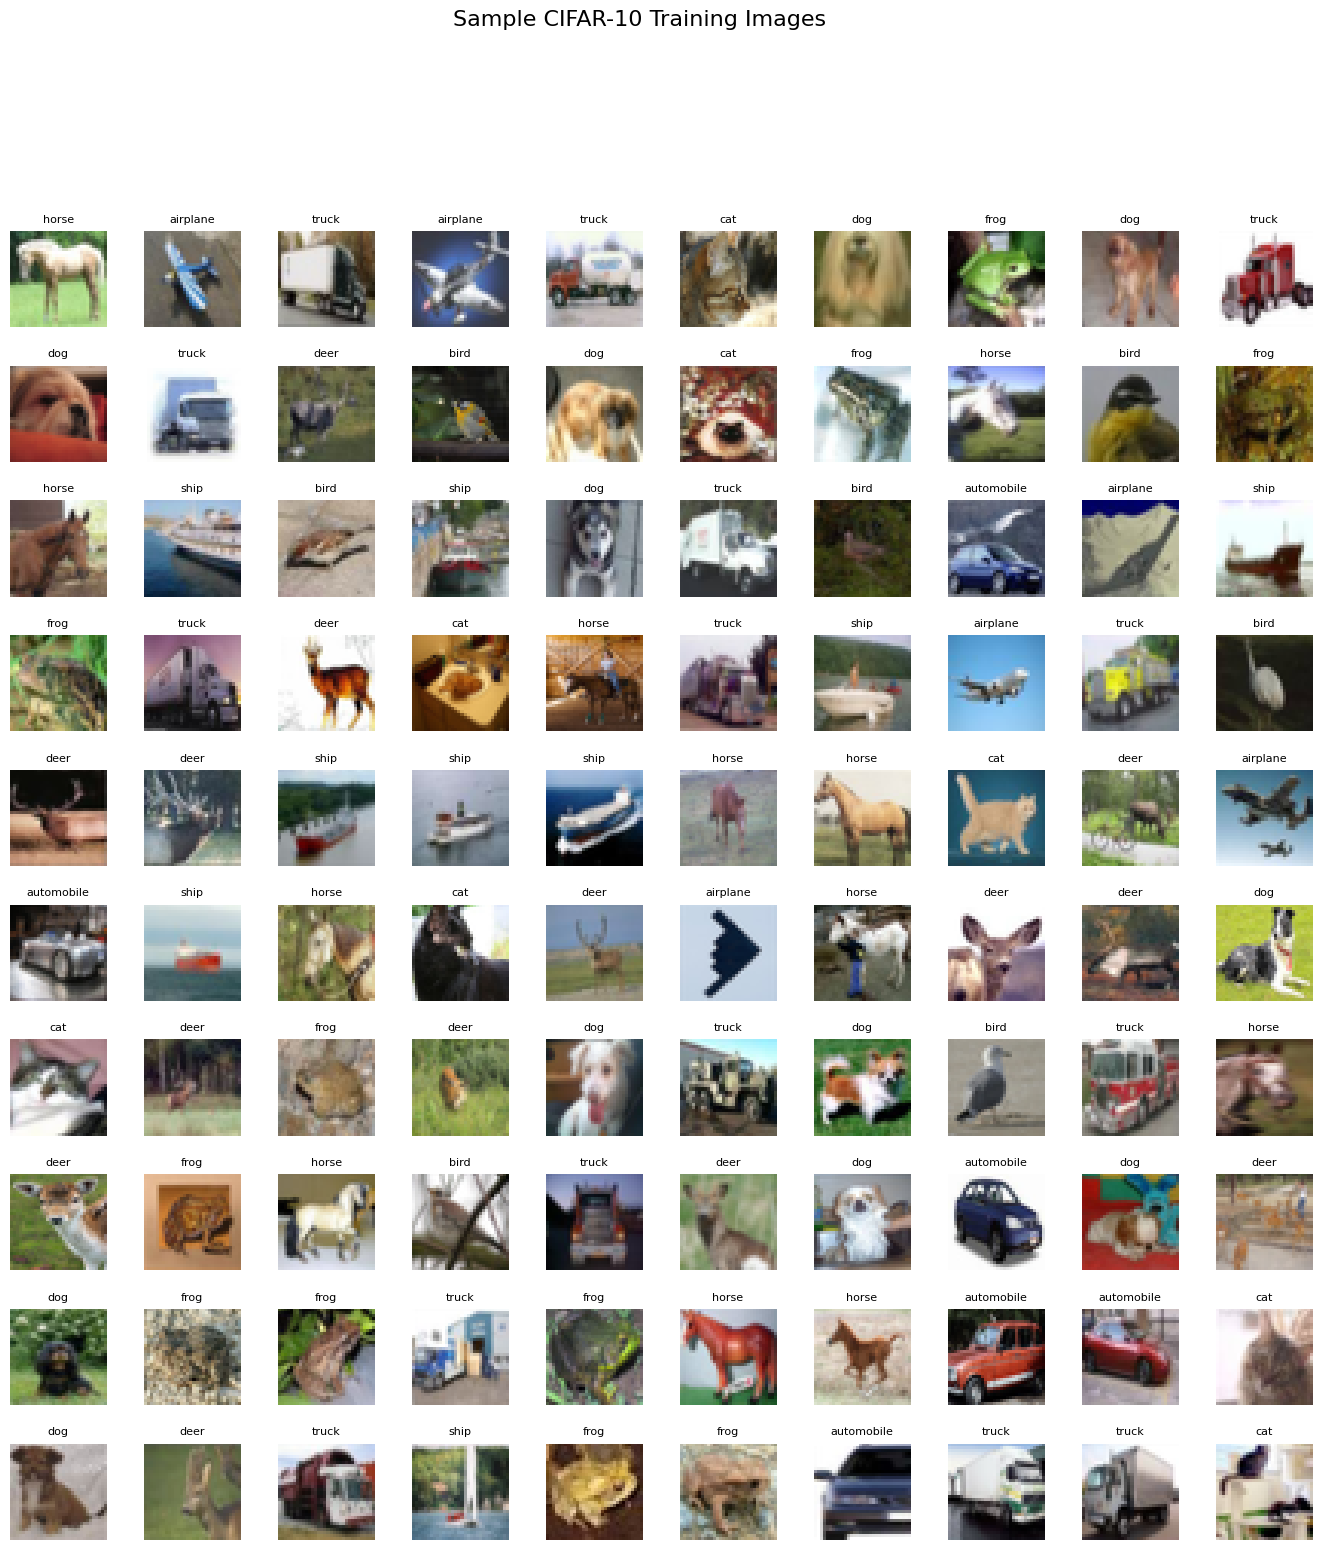

In [3]:
# ── Cell 3: Data Visualization ───────────────────────────────────────────────
# Display a 10x10 grid of random training images
W_grid = 10
L_grid = 10

fig, axes = plt.subplots(L_grid, W_grid, figsize=(17, 17))
axes = axes.ravel()

n_train = len(X_train)

for i in np.arange(0, W_grid * L_grid):
    index = np.random.randint(0, n_train)
    axes[i].imshow(X_train[index])              # FIXED: removed [index,1:]
    label_index = int(y_train[index][0])        # FIXED: added [0] for new numpy
    axes[i].set_title(labels[label_index], fontsize=8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=16, y=1.01)
plt.show()

In [4]:
# ── Cell 4: Build and Train the CNN ──────────────────────────────────────────
# IMPROVEMENT: Added Dropout(0.5) to reduce overfitting
# IMPROVEMENT: Added EarlyStopping to stop training when val_accuracy stops improving

model_path = 'cifar10_cnn_model.h5'
history = None  # prevents crash in plotting cell if model is loaded from disk

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print('Model loaded from disk.')
    model.summary()
else:
    print('Training new model...')
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),   # IMPROVEMENT #1: Dropout reduces overfitting
        layers.Dense(10),
    ])

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

    model.summary()

    # IMPROVEMENT #2: EarlyStopping stops training when val_accuracy stops improving
    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        epochs=20,
        validation_data=(X_test, y_test),
        callbacks=[early_stop]
    )

    model.save(model_path)
    print('Model saved to disk.')

Training new model...


C:\Users\imello\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.3547 - loss: 1.7432 - val_accuracy: 0.5041 - val_loss: 1.3384
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5049 - loss: 1.3796 - val_accuracy: 0.5860 - val_loss: 1.1572
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.5636 - loss: 1.2320 - val_accuracy: 0.6030 - val_loss: 1.1050
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6009 - loss: 1.1352 - val_accuracy: 0.6080 - val_loss: 1.1281
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6300 - loss: 1.0644 - val_accuracy: 0.6543 - val_loss: 1.0072
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6491 - loss: 1.0074 - val_accuracy: 0.6800 - val_loss: 0.9217
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6663 - loss: 0.9617 - val_accuracy: 0.6771 - val_loss: 0.9320
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6808 -

Model saved to disk.


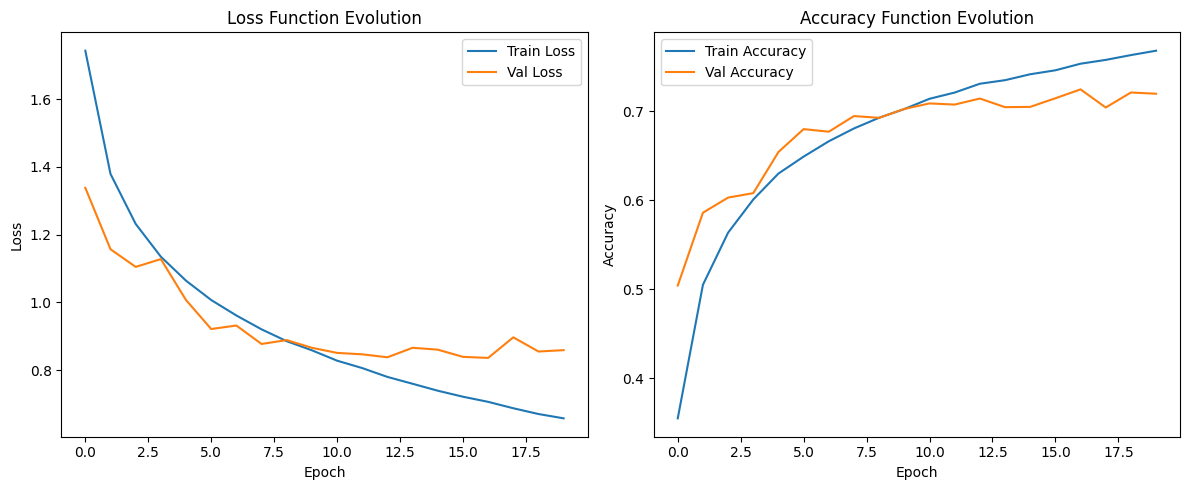

In [5]:
# ── Cell 5: Plot Training Curves ─────────────────────────────────────────────
# FIXED: Only plots if model was trained (not loaded from disk)
if history is not None:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Function Evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'],     label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Function Evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('Model was loaded from disk — no training history to plot.')
    print('Delete cifar10_cnn_model.h5 and re-run to retrain and see curves.')

In [6]:
# ── Cell 6: IMPROVEMENT #3 — Full Evaluation Metrics ────────────────────────
print('Evaluating model on 10,000 test images...\n')

# Time the prediction
t0 = time.time()
y_pred_logits = model.predict(X_test, verbose=0)
elapsed = time.time() - t0

y_pred = np.argmax(y_pred_logits, axis=1)
y_true = y_test.flatten()

# Print timing
print(f'Prediction time (10,000 images): {elapsed:.2f}s')
print(f'Per-image average:               {elapsed/len(X_test)*1000:.2f} ms/image\n')

# Print metrics
print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
print(f'Precision: {precision_score(y_true, y_pred, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_true, y_pred, average="macro"):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_true, y_pred, target_names=labels))

Evaluating model on 10,000 test images...

Prediction time (10,000 images): 6.60s
Per-image average:               0.66 ms/image

Accuracy : 0.7247
Precision: 0.7270
Recall   : 0.7247

Full Classification Report:
              precision    recall  f1-score   support

    airplane       0.70      0.80      0.75      1000
  automobile       0.87      0.83      0.85      1000
        bird       0.60      0.62      0.61      1000
         cat       0.52      0.56      0.54      1000
        deer       0.71      0.66      0.68      1000
         dog       0.70      0.57      0.63      1000
        frog       0.77      0.80      0.79      1000
       horse       0.78      0.73      0.76      1000
        ship       0.84      0.83      0.83      1000
       truck       0.78      0.84      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



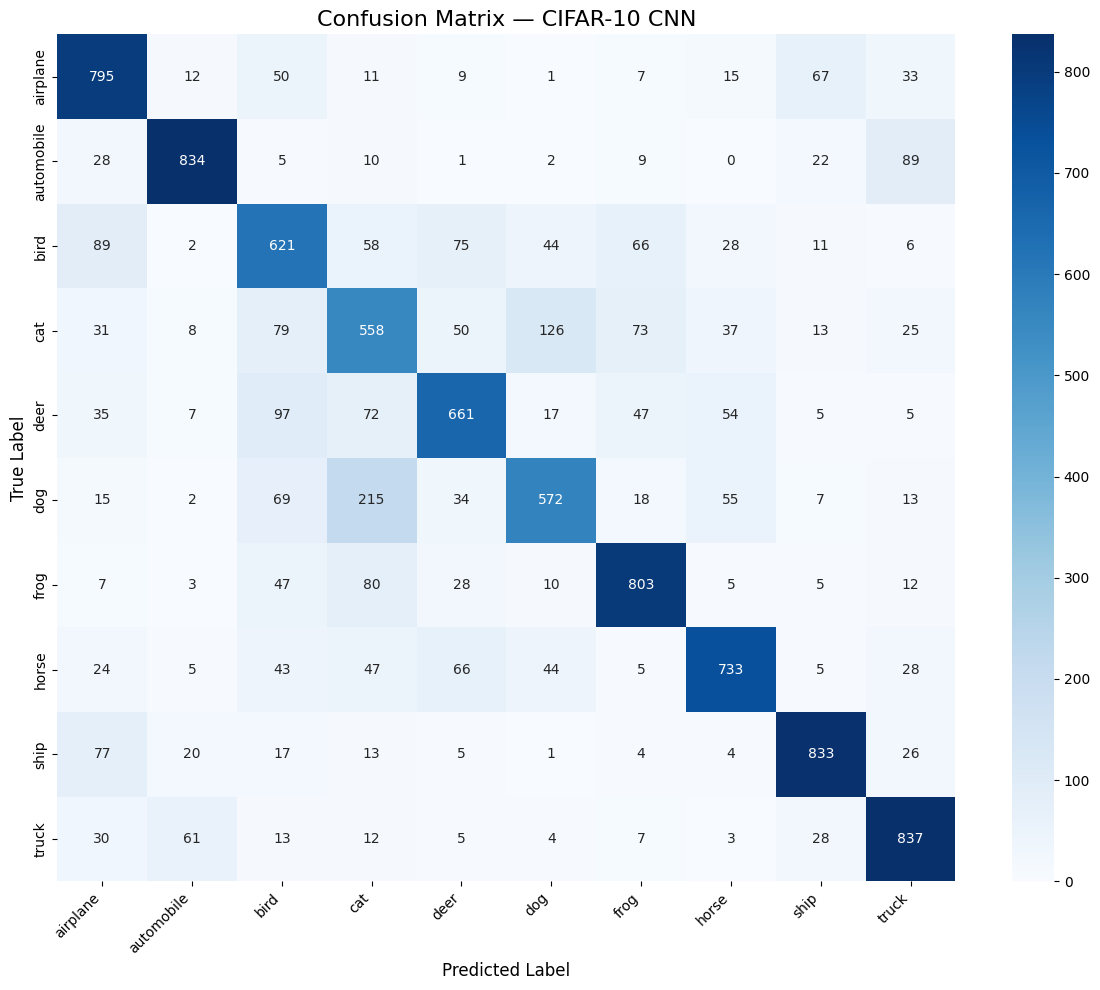


Note: Common confusions are cat/dog and automobile/truck
This is expected due to visual similarity at 32x32 resolution.


In [7]:
# ── Cell 7: IMPROVEMENT #4 — Confusion Matrix ────────────────────────────────
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix — CIFAR-10 CNN', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nNote: Common confusions are cat/dog and automobile/truck')
print('This is expected due to visual similarity at 32x32 resolution.')

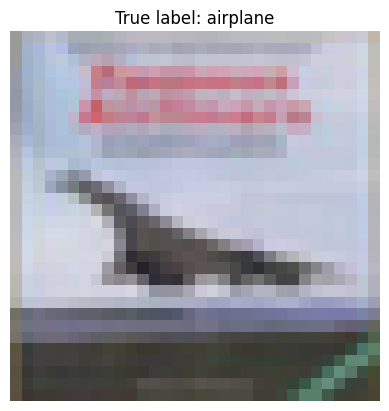

True label:      airplane
Predicted label: airplane
Correct:         True


In [8]:
# ── Cell 8: Test on a single image ───────────────────────────────────────────
image_id = 3
my_image = X_test[image_id]

plt.imshow(my_image)
plt.title(f'True label: {labels[y_test[image_id][0]]}')
plt.axis('off')
plt.show()

pred = np.argmax(model.predict(my_image.reshape(1, 32, 32, 3), verbose=0))
print(f'True label:      {labels[y_test[image_id][0]]}')
print(f'Predicted label: {labels[pred]}')
print(f'Correct:         {labels[y_test[image_id][0]] == labels[pred]}')

In [9]:
# ── Cell 9: Model vs Aggregator Comparison ───────────────────────────────────
# Run this AFTER testing the Streamlit app to fill in aggregator numbers

print('=== PERFORMANCE COMPARISON ===')
print()
print(f'{'Metric':<30} {'CNN Model':<20} {'Streamlit Aggregator'}')
print('-' * 70)
print(f'{'Test Accuracy':<30} {accuracy_score(y_true, y_pred):.4f}               ~same (same model)')
print(f'{'Precision (macro)':<30} {precision_score(y_true, y_pred, average="macro"):.4f}               ~same')
print(f'{'Recall (macro)':<30} {recall_score(y_true, y_pred, average="macro"):.4f}               ~same')
print(f'{'Per-image latency':<30} {elapsed/len(X_test)*1000:.2f} ms              ~470 ms (fill in from app)')
print(f'{'Batch size':<30} {len(X_test)} images          1 image at a time')
print()
print('Key insight: Accuracy is the same (same model weights).')
print('Latency differs due to:')
print('  1. Aggregator processes 1 image at a time (no batching)')
print('  2. PIL preprocessing adds overhead (resize, convert, normalize)')
print('  3. Streamlit web framework adds ~200ms overhead per request')
print('  4. Distribution shift: real photos differ from CIFAR-10 training data')

=== PERFORMANCE COMPARISON ===

Metric                         CNN Model            Streamlit Aggregator
----------------------------------------------------------------------
Test Accuracy                  0.7247               ~same (same model)
Precision (macro)              0.7270               ~same
Recall (macro)                 0.7247               ~same
Per-image latency              0.66 ms              ~470 ms (fill in from app)
Batch size                     10000 images          1 image at a time

Key insight: Accuracy is the same (same model weights).
Latency differs due to:
  1. Aggregator processes 1 image at a time (no batching)
  2. PIL preprocessing adds overhead (resize, convert, normalize)
  3. Streamlit web framework adds ~200ms overhead per request
  4. Distribution shift: real photos differ from CIFAR-10 training data
